In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Đọc dữ liệu

In [3]:
# Lấy file train để phân tích thăm dò dữ liệu
df = pd.read_csv('D:\\DS111\\DoAnDS111\\banking_dataset\\train.csv', sep=";")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
df.shape

(45211, 17)

In [5]:
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [6]:
# Kiểm tra giá trị duy nhất trong mỗi cột
df.nunique()

age            77
job            12
marital         3
education       4
default         2
balance      7168
housing         2
loan            2
contact         3
day            31
month          12
duration     1573
campaign       48
pdays         559
previous       41
poutcome        4
y               2
dtype: int64

In [7]:
# Kiểm tra giá trị thiếu trong mỗi cột
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [8]:
# Thống kê mô tả dữ liệu số
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [9]:
# Thống kê mô tả dữ liệu phân loại
df.describe(include=['object'])

,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
unique,12,3,4,2,2,2,3,12,4,2
top,blue-collar,married,secondary,no,yes,no,cellular,may,unknown,no
freq,9732,27214,23202,44396,25130,37967,29285,13766,36959,39922


## Phân tích thăm dò (EDA)

Trước khi đi vào phần EDA, nhìn lại phần thông tin ở trên, ta thấy được bộ dữ liệu có 7 cột là dữ liệu số (numeric), 10 cột là dữ liệu phân loại (categorical) và không có missing value. Tuy nhiên, để có thể hiểu sâu hơn về các giá trị và dữ liệu thì phải phân tích thăm dò sâu hơn nữa để hiểu rõ hơn về các biến và các con số nó đang đại diện và mang ý nghĩa gì.

Nguồn tham khảo: https://www.kaggle.com/code/dunnguynduy/bank-marketing-eda

Sau khi đọc qua khá nhiều nguồn code về phân tích thăm dò (EDA) và tiền xử lý dữ liệu (preprocessing data) thì nguồn trên là 1 trong những nguồn phân tích chi tiết và đi vào đúng trọng tâm của bài toán là phân tích hành vi và xem xem những nhóm khách hàng nào có khả năng cao sẽ đăng ký gửi tiền tại ngân hàng này. 

Phân tích thăm dò ở đây là sẽ đi xem xét từng cột trong bộ dữ liệu, xem xem nó biểu diễn những gì, có gì bất thường hay không, trực quan nó lên để hiểu rõ hơn về cách dữ liệu đang "nói" và đó cũng tạo một tiền đề để các bước sau như tiền xử lý và mô hình hóa dữ liệu có thể biểu diễn tốt hơn. Dưới đây là phần phân tích thăm dò của bộ dữ liệu Banking Marketing.

#### age
Theo dữ liệu từ phần thống kê mô tả, có thể thấy được:
- Độ tuổi nhỏ nhất là 18, lớn nhất là 95
- Cần vẽ histogram để đếm số lượng theo từng độ tuổi, khi đó ta cần số lượng bins (số lượng hoặc khoảng nhóm mà dữ liệu được chia ra để vẽ biểu đồ histogram) = 95-18 +1.
- Sau khi vẽ xong histogram đầu tiên, có thể thấy rõ là phần lớn lượng khách hàng sẽ nằm trong độ tuổi từ 25 đến 60
- Từ đó, ta thử vẽ một boxplot để xét xem các outliers, ta cũng thấy phần dữ liệu về độ tuổi lớn hơn 70 đang có vẻ là outliers
- Cuối cùng, vẽ lại 1 histogram theo độ tuổi sau khi đã loại bỏ đi các outliers => Điều này giúp biểu đồ rõ ràng hơn và phản ánh phân bố tuổi phổ biến trong nhóm khách hàng chính.

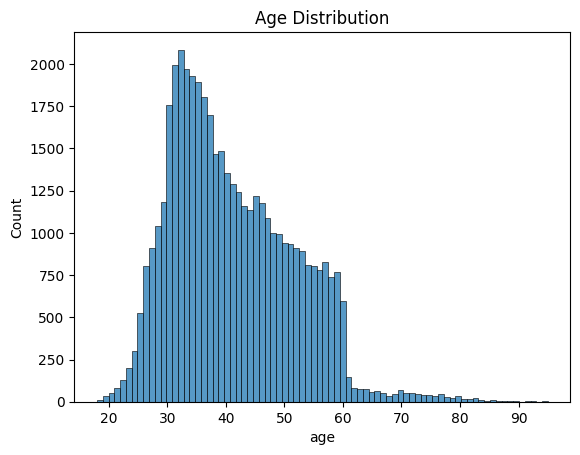

In [10]:
# Vẽ biểu đồ phân phối độ tuổi
sns.histplot(df['age'], bins=95-18+1)
plt.title('Age Distribution')
plt.show()

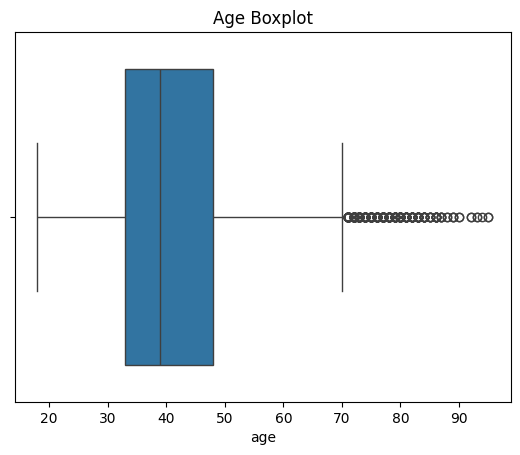

In [11]:
# Vẽ biểu đồ hộp độ tuổi, kiểm tra ngoại lệ
sns.boxplot(df['age'], orient='h')
plt.title('Age Boxplot')
plt.show()

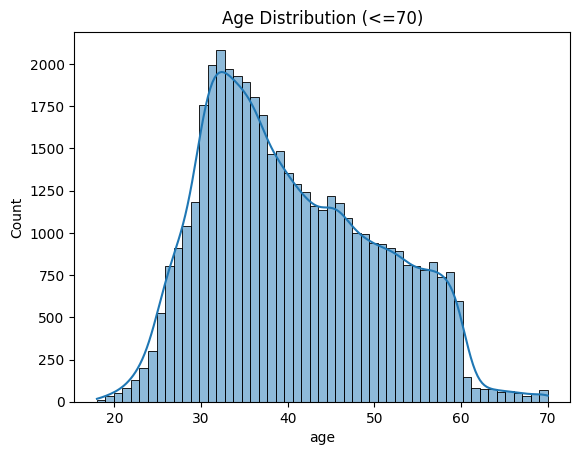

In [12]:
# Lọc bỏ ngoại lệ độ tuổi lớn hơn 70
new_age = df['age'][df['age'] <= 70]
sns.histplot(new_age, bins=70-18+1, kde=True)
plt.title('Age Distribution (<=70)')
plt.show()

#### Job
- Theo dữ liệu từ thống kê mô tả, khách hàng có job là blue-collar nhiều nhất
- Đầu tiên, vẽ 1 countplot để xem các giá trị của từng job trong columns
- Sau khi vẽ xong, có thể thấy được, phần unknown chiếm 1 khoảng nhỏ (có thể sẽ là giá trị thiếu, nan,...) và phần student là nhóm có số lượng ít thứ 2 sau unknown

C:\Users\Admin\AppData\Local\Temp\ipykernel_21884\2024474133.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df, x='job', palette='Set3', legend=False)


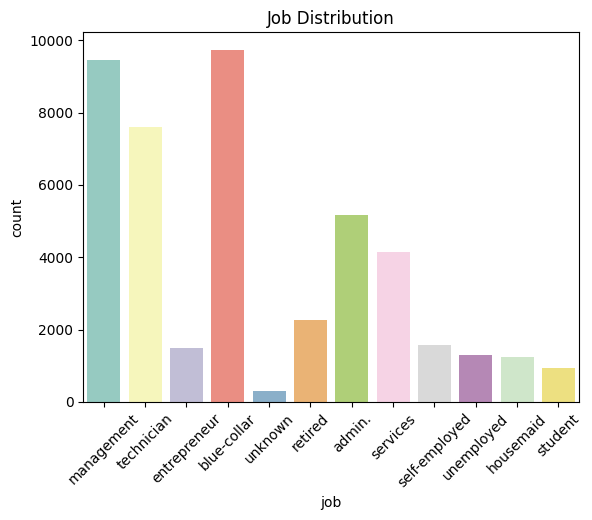

In [13]:
# Vẽ biểu đồ phân phối nghề nghiệp nhiều màu khác nhau
sns.countplot(df, x='job', palette='Set3', legend=False)
plt.title('Job Distribution')
plt.xticks(rotation=45)
plt.show()

#### Marital
- Theo dữ liệu thống kê mô tả, khách hàng ở trạng thái married có số lượng cao nhất
- Sau khi vẽ thì có thể thấy số lượng khách ở trạng thái single nhiều thứ 2 và cuối cùng là divorced

C:\Users\Admin\AppData\Local\Temp\ipykernel_21884\4210727060.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df, x='marital', palette='Set1', legend=False)


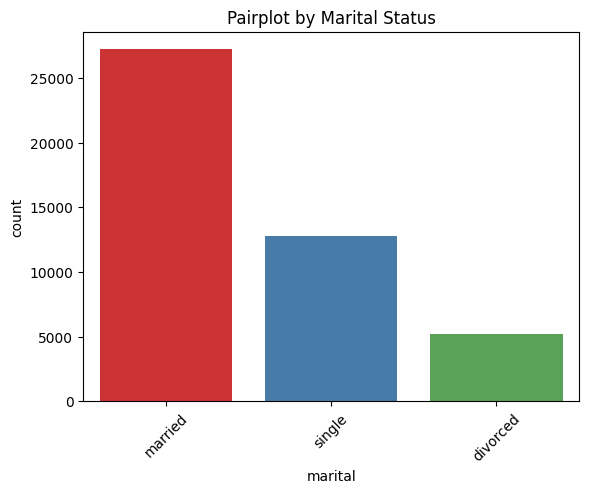

In [14]:
# Vẽ biểu đồ phân phối trạng thái hôn nhân
sns.countplot(df, x='marital', palette='Set1', legend=False)
plt.xticks(rotation=45)
plt.title('Pairplot by Marital Status')
plt.show()

#### education
- Nhóm khách hàng có trình độ trung học (secondary) chiếm số lượng nhiều nhất trong dữ liệu.
- Có một giá trị đặc biệt “unknown” trong cột education => Giá trị này có thể coi là dữ liệu bị thiếu (missing value), và số lượng bản ghi này là ít nhất so với các nhóm khác.
- Nhóm khách hàng có trình độ tiểu học (primary) là nhóm ít nhất trong số các giá trị có ý nghĩa, xếp thứ hai về số lượng ít nhất.

C:\Users\Admin\AppData\Local\Temp\ipykernel_21884\2151648203.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df, x='education', palette='Set2', legend=False)


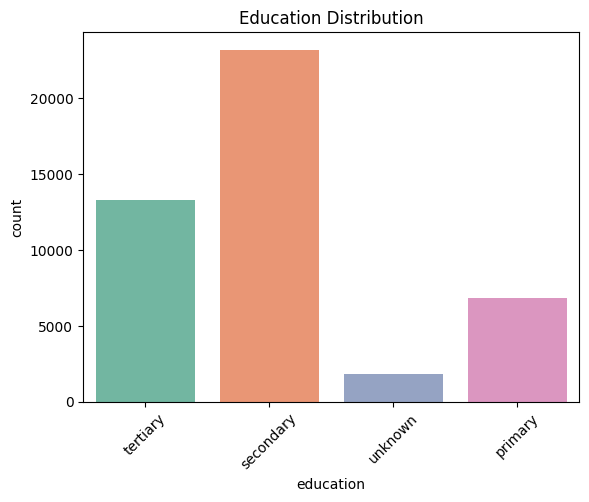

In [15]:
# Vẽ biểu đồ phân phối trình độ học vấn
sns.countplot(df, x='education', palette='Set2', legend=False)
plt.title('Education Distribution')
plt.xticks(rotation=45)
plt.show()

#### default
- Cột này biểu thị khách hàng có khoản nợ tín dụng quá hạn (default) hay không.
    - Quan sát dữ liệu cho thấy đa số khách hàng không có nợ quá hạn.
    - Phần lớn giá trị của cột này là “no” (không có nợ quá hạn), và chỉ một số rất ít khách hàng có nợ quá hạn.

C:\Users\Admin\AppData\Local\Temp\ipykernel_21884\588691415.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df, x='default', palette='Set1', legend=False)


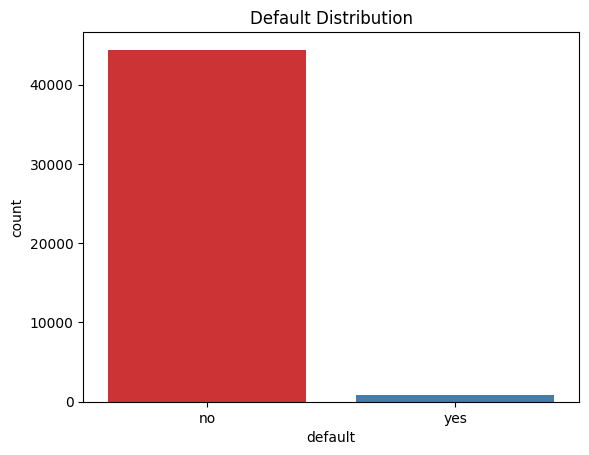

In [16]:
# Vẽ biểu đồ phân phối có nợ hay không
sns.countplot(df, x='default', palette='Set1', legend=False)
plt.title('Default Distribution')
plt.show()

#### Balance
- "balance" biểu diễn số dư trung bình hằng năm của khách hàng
- Theo dữ liệu thống kê mô tả:
    - Giá trị nhỏ nhất (min) = –8019
    - Giá trị lớn nhất (max) = 102127
    - Giá trị trung bình (mean) ≈ 1362
    - Độ lệch chuẩn (std) = 3044
=> Điều này cho thấy dữ liệu trải dài và rộng, biến động mạnh với max rất cao và min rất thấp, std cao cho thấy dữ liệu bị phân tán khá nhiều và có thể "balance" sẽ chứa nhiều outliers
- Quan sát histogram và boxplot, ta thấy được tần suất xuất hiện của các giá trị balance và các outliers trong dữ liệu, từ đó xác định khoảng nào cần được bỏ đi => Sau khi bỏ đi các outliers giúp ta nhận ra được các giá trị một cách trực quan hơn

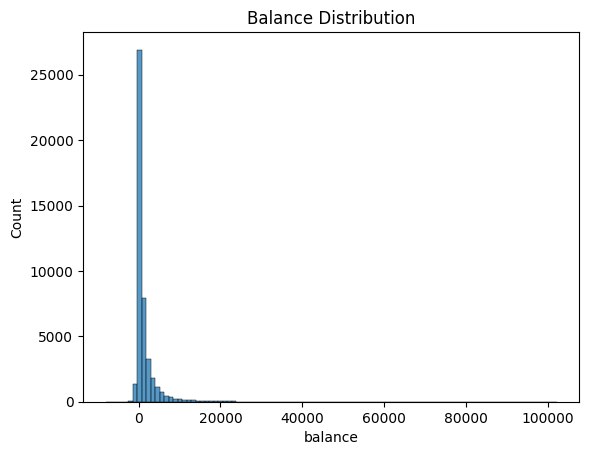

In [17]:
# Vẽ biểu đồ phân phối số dư tài khoản
sns.histplot(data=df, x='balance', bins=100)
plt.title('Balance Distribution')
plt.show()

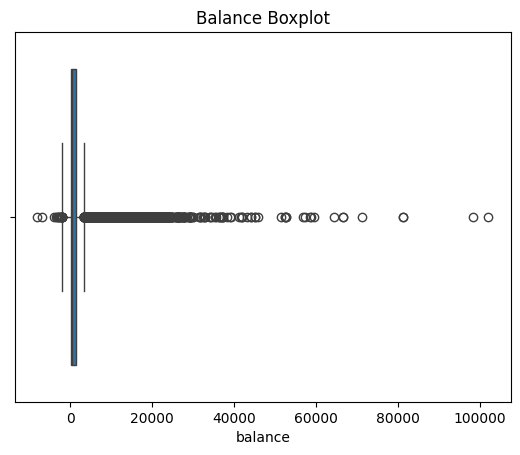

In [18]:
# Vẽ biểu đồ hộp số dư tài khoản, kiểm tra ngoại lệ
sns.boxplot(x=df['balance'], orient='h')
plt.title('Balance Boxplot')
plt.show()

In [19]:
# Kiểm tra IQR của balance
Q1 = np.percentile(df['balance'], 25)
Q3 = np.percentile(df['balance'], 75)
IQR = Q3 - Q1
lower_whisker = Q1 - 1.5 * IQR
upper_whisker = Q3 + 1.5 * IQR
print(f"IQR: {IQR},\nLower Whisker: {lower_whisker}, \nUpper Whisker: {upper_whisker}")

IQR: 1356.0,
Lower Whisker: -1962.0, 
Upper Whisker: 3462.0


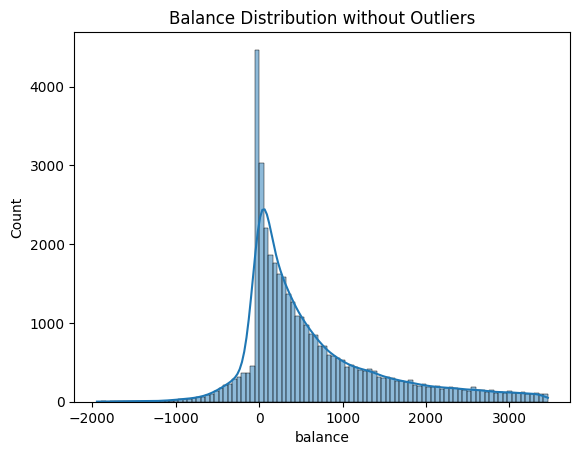

In [20]:
# Lọc bỏ ngoại lệ của balance
new_balance = df['balance'][(df['balance'] <= upper_whisker) & (df['balance'] >= lower_whisker)]
sns.histplot(new_balance, bins=100, kde=True)
plt.title('Balance Distribution without Outliers')
plt.show()

#### housing
- Cột này biểu diễn giá trị yes/no với khách hàng có vay nợ mua nhà không
- Sau khi trực quan dữ liệu thì ta thấy:
    - 55.6% khách hàng có khoản vay mua nhà
    - 44.4% khách hàng không có khoản vay

C:\Users\Admin\AppData\Local\Temp\ipykernel_21884\3991679360.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df, x='housing', palette='Set2', legend=False)


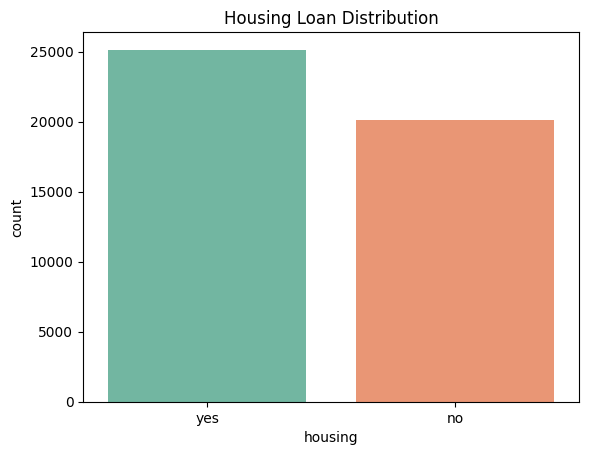

In [21]:
# Vẽ biểu đồ phân phối có vay nhà hay không
sns.countplot(df, x='housing', palette='Set2', legend=False)
plt.title('Housing Loan Distribution')
plt.show()

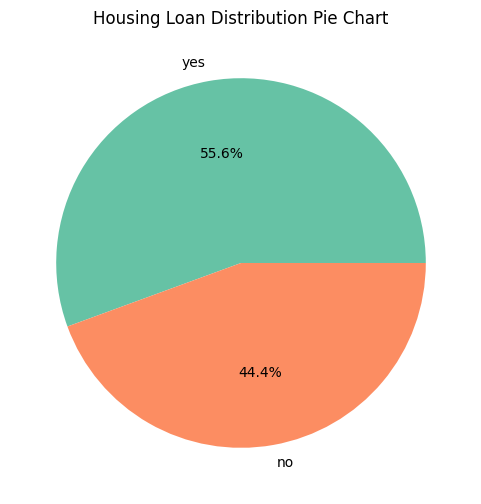

In [22]:
# Tính phân phối của housing loan
housing_counts = df['housing'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(housing_counts, labels=housing_counts.index, autopct='%1.1f%%', colors=sns.color_palette('Set2'))
plt.title('Housing Loan Distribution Pie Chart')
plt.show()

#### loan
 - Biểu diễn khách hàng có nợ cá nhân không
 - Phần lớn khách hàng không có nợ cá nhân, số người có ít.

C:\Users\Admin\AppData\Local\Temp\ipykernel_21884\2540402068.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df, x='loan', palette='Set1', legend=False)


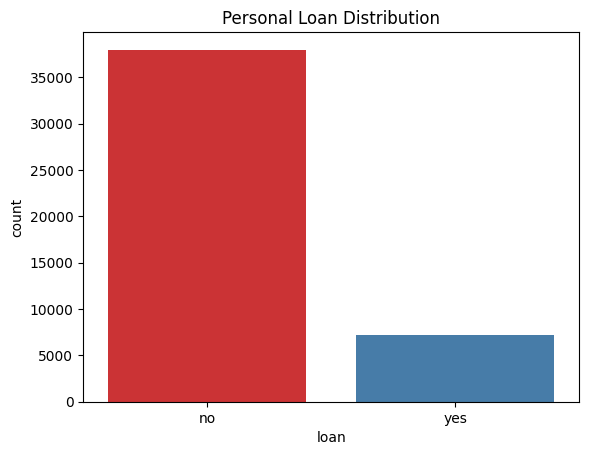

In [23]:
# Vẽ biểu đồ phân phối có vay cá nhân hay không
sns.countplot(df, x='loan', palette='Set1', legend=False)
plt.title('Personal Loan Distribution')
plt.show()

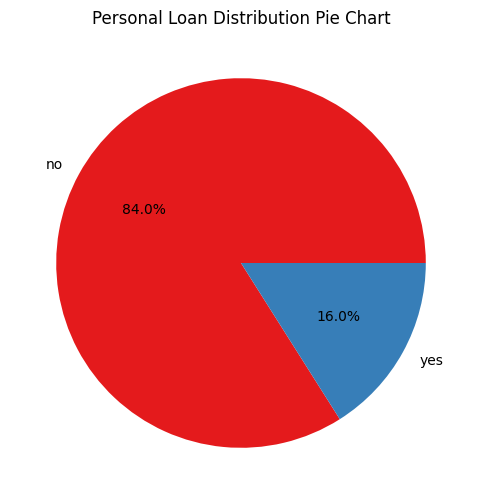

In [24]:
# Tính phân phối của personal loan
loan_counts = df['loan'].value_counts(normalize=True) * 100
plt.figure(figsize=(6, 6))
plt.pie(loan_counts, labels=loan_counts.index, autopct='%1.1f%%', colors=sns.color_palette('Set1'))
plt.title('Personal Loan Distribution Pie Chart')   
plt.show()

#### contact
- Biểu diễn phương thức liên lạc
- Trong dữ liệu có "unknown" -> có thể xem là giá trị thiếu (missing values)
- Hầu hết phương thức liên lạc là cellular

C:\Users\Admin\AppData\Local\Temp\ipykernel_21884\4113966015.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df , x = "contact", palette='Set3')


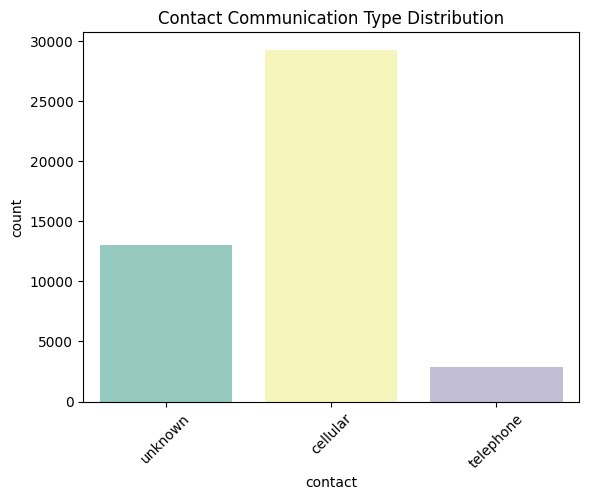

In [25]:
# Vẽ biểu đồ phân phối loại hình liên lạc
sns.countplot(df , x = "contact", palette='Set3')
plt.title('Contact Communication Type Distribution')
plt.xticks(rotation = 45)
plt.show()

#### day
- Biểu diễn ngày cuối cùng liên lạc với khách hàng trong tháng

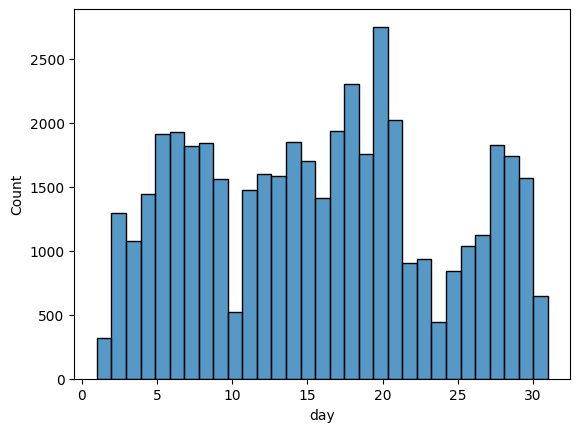

In [26]:
# Vẽ biểu đồ phân phối trong ngày liên lạc với khách hàng
sns.histplot(df["day"] , bins = 31) # để mặc định 31 ngày
plt.show()

#### month
- Biểu diễn tháng cuối cùng liên lạc trong 1 năm
- Theo dữ liệu, có thể thấy May (tháng 5) là tháng có tần suất liên lạc nhiều nhất, nhỏ nhất là December (tháng 12)


C:\Users\Admin\AppData\Local\Temp\ipykernel_21884\453273421.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df , x = "month", palette='Set3', legend=False)


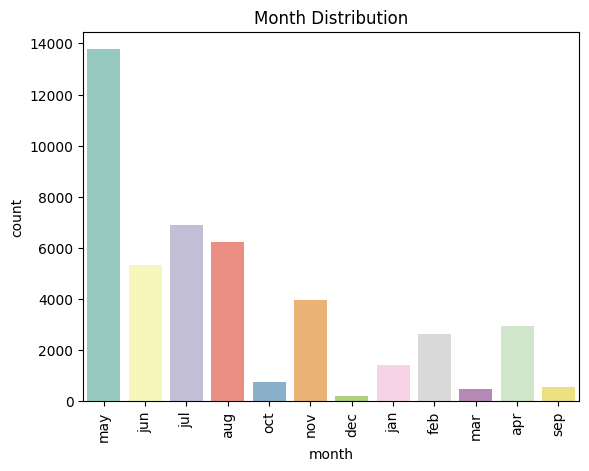

In [27]:
# Vẽ biểu đồ phân phối trong tháng liên lạc với khách hàng
sns.countplot(df , x = "month", palette='Set3', legend=False)
plt.title('Month Distribution')
plt.xticks(rotation = 90)
plt.show()

#### duration
- Biểu diễn thời lượng của lần liên hệ gần nhất với khách hàng (tính bằng giây).
- Theo dữ liệu thống kê mô tả: 
    - Giá trị nhỏ nhất (min) = 0
    - Giá trị lớn nhất (max) = 4918
    - Giá trị trung bình (mean) ≈ 258
    - Độ lệch chuẩn (std) = 257
=> Điều này cho thấy dữ liệu có độ biến thiên lớn, std cao nên dữ liệu có độ phân tán rộng => cột “duration” chứa nhiều giá trị ngoại lai (outliers), đặc biệt là đối với các cuộc gọi bất thường kéo dài rất lâu.
- Theo biểu đồ, histogram thể hiện tần suất xuất hiện các giá trị duration trong khi boxplot cho ta thấy rõ các giá trị outliers -> từ đó vẽ 1 histogram không có outliers

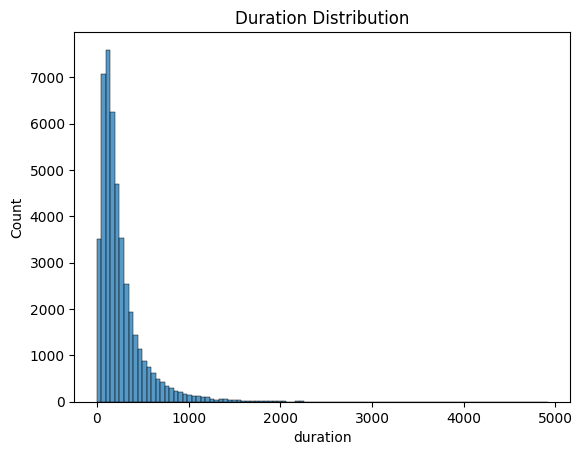

In [28]:
# Vẽ biểu đồ phân phối số lần liên lạc trong chiến dịch
sns.histplot(df['duration'], bins=100)
plt.title('Duration Distribution')
plt.show()

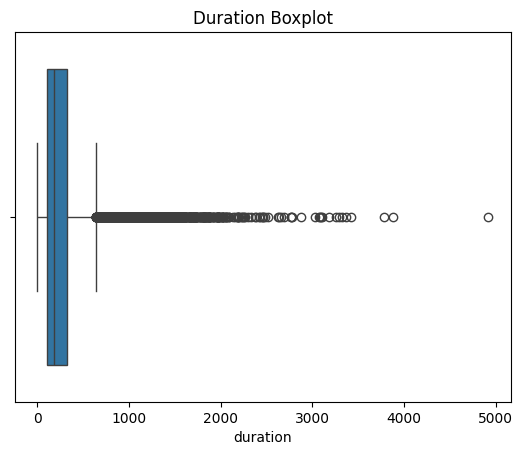

In [29]:
# Vẽ biểu đồ hộp số lần liên lạc trong chiến dịch, kiểm tra ngoại lệ
sns.boxplot(x=df['duration'], orient='h')
plt.title('Duration Boxplot')
plt.show()

In [30]:
# Kiểm tra IQR của duration
duration_data = df["duration"]

Q1 = np.percentile(duration_data, 25)
Q3 = np.percentile(duration_data, 75)

IQR = Q3 - Q1
upper_whisker = Q3 + 1.5 * IQR

print("Upper whisker:", upper_whisker)

Upper whisker: 643.0


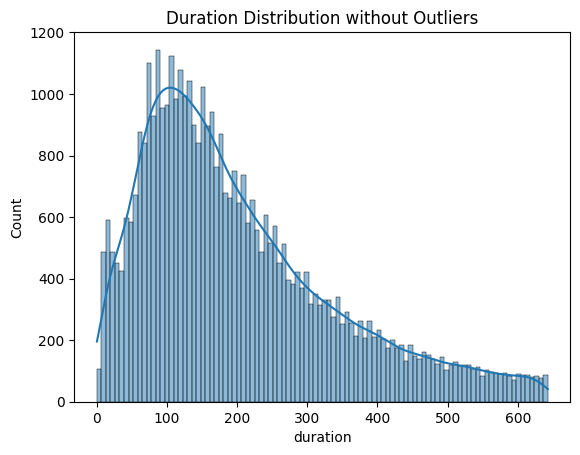

In [31]:
# Vẽ biểu đồ phân phối của duration không có outlier
new_duration = df['duration'][df['duration'] <= upper_whisker]
sns.histplot(new_duration, bins=100, kde=True)
plt.title('Duration Distribution without Outliers')
plt.show()

#### campaign
- Biểu diễn số lần liên hệ được thực hiện với khách hàng trong chiến dịch hiện tại.
- Theo dữ liệu thống kê mô tả:
    - Giá trị nhỏ nhất (min) = 1
    - Giá trị lớn nhất (max) = 63
    - Giá trị trung bình (mean) ≈ 2.76
    - Độ lệch chuẩn (std) ≈ 3
=> Điều này cho thấy phần lớn khách hàng được liên hệ khoảng 1–3 lần, nhưng cũng tồn tại những trường hợp hiếm được liên hệ nhiều lần (ví dụ 20–60 lần), gây nên sự phân tán lớn trong dữ liệu.
- Histogram cho thấy tần suất của số lần liên hệ trong chiến dịch và boxplot trực quan rõ sự tồn tại của các outliers -> vẽ 1 histogram khác không có outliers -> giúp biểu đồ rõ ràng hơn, thể hiện đúng xu hướng của phần lớn dữ liệu.

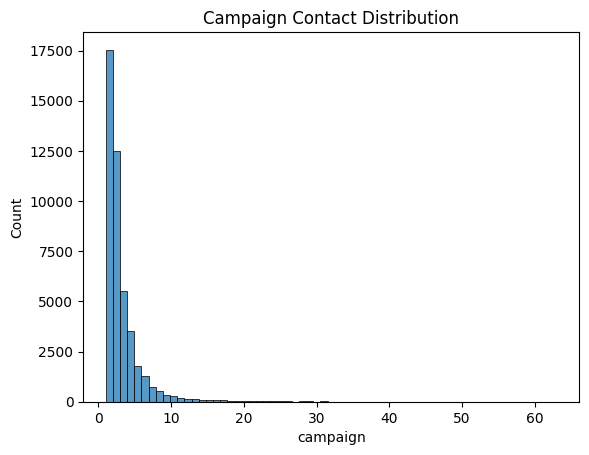

In [32]:
# Vẽ biểu đồ phân phối số lần liên lạc trong chiến dịch
sns.histplot(df, x='campaign', bins=63)
plt.title('Campaign Contact Distribution')
plt.show()

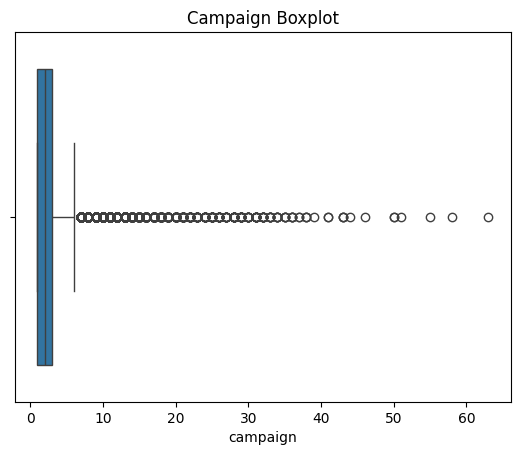

In [33]:
# Vẽ biểu đồ hộp số lần liên lạc trong chiến dịch, kiểm tra ngoại lệ
sns.boxplot(x=df['campaign'], orient='h')
plt.title('Campaign Boxplot')
plt.show()

In [34]:
# Kiểm tra IQR của campaign
campaign_data = df["campaign"]
Q1 = np.percentile(campaign_data, 25)
Q3 = np.percentile(campaign_data, 75)
IQR = Q3 - Q1
upper_whisker = Q3 + 1.5 * IQR
print("Upper whisker:", upper_whisker)

Upper whisker: 6.0


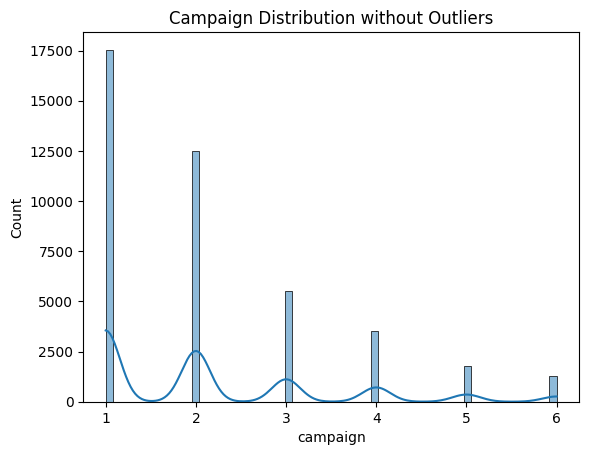

In [35]:
# Vẽ biểu đồ phân phối của campaign không có outlier
new_campaign = df['campaign'][df['campaign'] <= upper_whisker]
sns.histplot(new_campaign, bins=63, kde=True)
plt.title('Campaign Distribution without Outliers')
plt.show()

#### pdays
- Cột này cho biết số ngày đã trôi qua kể từ lần cuối cùng khách hàng được liên hệ trong chiến dịch trước đó.
- Nếu giá trị là -1, điều đó có nghĩa là khách hàng chưa từng được liên hệ trước đây.
(Tức là không có chiến dịch trước hoặc khách hàng không nằm trong danh sách liên hệ trước đó.)
- Sau khi biểu diễn histogram và boxplot -> nhận thấy có outliers -> tiến hành tính toán và xử lý -> tuy nhiên khi đã xử lý outliers > -1 rồi mà vẫn còn -> lồng thêm 1 bước lọc -> ta loại được các outliers >= 618 -> vẽ được histogram mới trực quan và tường minh hơn.

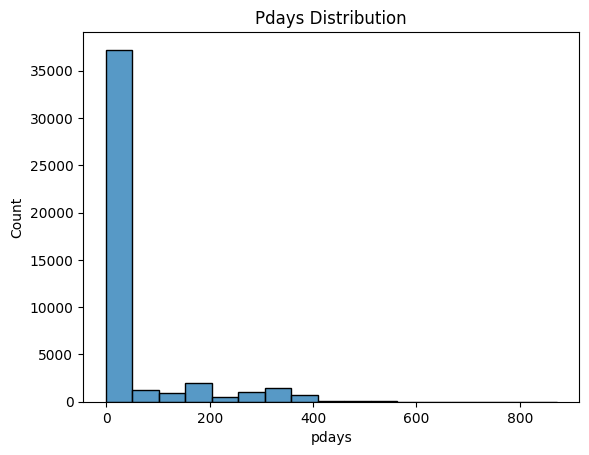

In [36]:
# Vẽ biểu đồ phân phối số ngày kể từ lần liên lạc cuối cùng
sns.histplot(df['pdays'])
plt.title('Pdays Distribution')
plt.show()

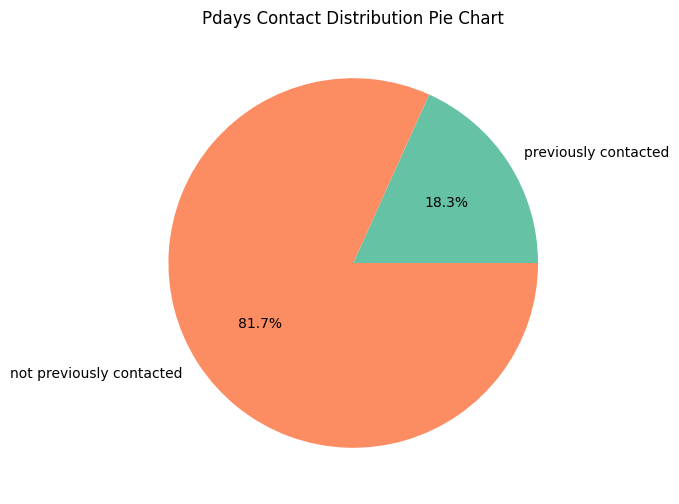

In [37]:
# Vẽ biểu đồ phân phối số ngày kể từ lần liên lạc cuối cùng, kiểm tra ngoại lệ
pos_pdays_counts = df['pdays'][df['pdays'] > -1].count()
neg_pdays_counts = df['pdays'][df['pdays'] == -1].count()

labels = ['previously contacted', 'not previously contacted']
counts = [pos_pdays_counts, neg_pdays_counts]

plt.figure(figsize=(6,6))
plt.pie(counts, labels=labels, autopct='%1.1f%%', colors=sns.color_palette('Set2'))
plt.title('Pdays Contact Distribution Pie Chart')
plt.show()

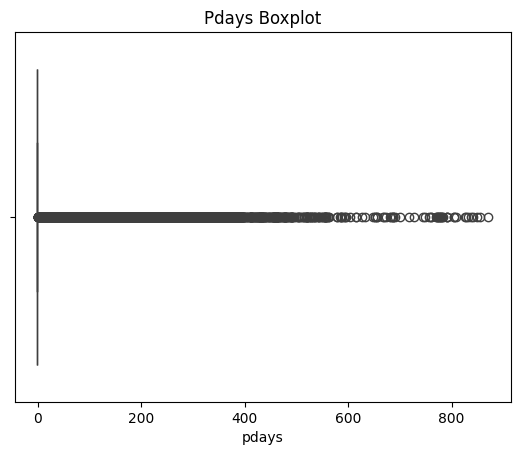

In [38]:
# Vẽ biểu đồ hộp số ngày kể từ lần liên lạc cuối cùng, kiểm tra ngoại lệ
sns.boxplot(df['pdays'], orient='h')
plt.title('Pdays Boxplot')
plt.show()

In [39]:
# Kiểm tra IQR của pdays
campaign_data = df["pdays"]
Q1 = np.percentile(campaign_data, 25)
Q3 = np.percentile(campaign_data, 75)
IQR = Q3 - Q1
lower_whisker = Q1 - 1.5 * IQR
upper_whisker = Q3 + 1.5 * IQR
print(f"IQR: {IQR},\nLower whisker: {lower_whisker}, \nUpper whisker: {upper_whisker}")


IQR: 0.0,
Lower whisker: -1.0, 
Upper whisker: -1.0


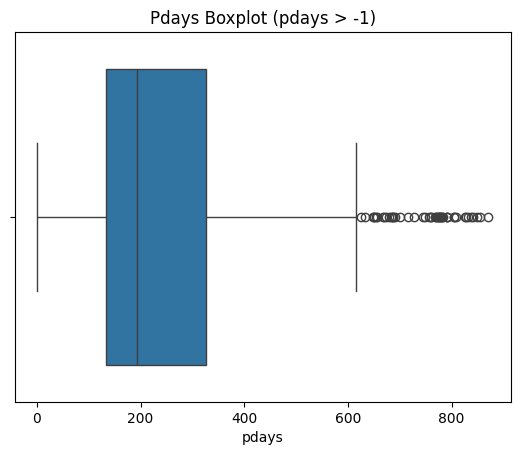

In [40]:
# Kiểm tra thử với boxplot nếu pdasy > -1
sns.boxplot(df['pdays'][df['pdays'] > -1], orient='h')
plt.title('Pdays Boxplot (pdays > -1)')
plt.show()

In [41]:
# Tính tiếp IQR nếu chỉ xét pdays > -1
new_pdays = df['pdays'][df['pdays'] > -1]
Q1 = np.percentile(new_pdays, 25)
Q3 = np.percentile(new_pdays, 75)
IQR = Q3 - Q1
upper_whisker = Q3 + 1.5 * IQR
print(f"IQR: {IQR},\nUpper whisker: {upper_whisker}")

IQR: 194.0,
Upper whisker: 618.0


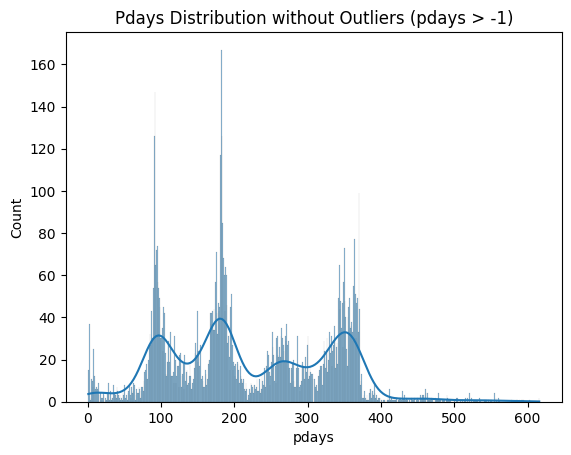

In [42]:
# Vẽ lại histogram không có outlier pdays > -1
new_pdays1 = df['pdays'][(df['pdays'] > -1) & (df['pdays'] <= upper_whisker)]
sns.histplot(new_pdays1, bins=619, kde=True)
plt.title('Pdays Distribution without Outliers (pdays > -1)')
plt.show()

#### previous
- Cột này cho biết số lần liên hệ đã được thực hiện với khách hàng trước chiến dịch hiện tại.


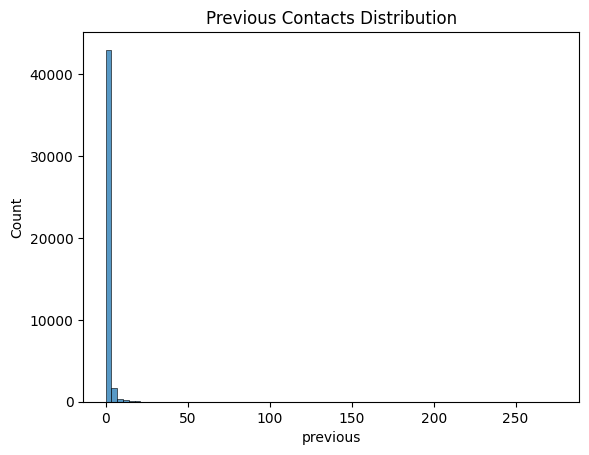

In [43]:
# Vẽ biểu đồ phân phối số lần liên lạc trong chiến dịch
sns.histplot(df['previous'], bins=95-18+1 )
plt.title('Previous Contacts Distribution')
plt.show()

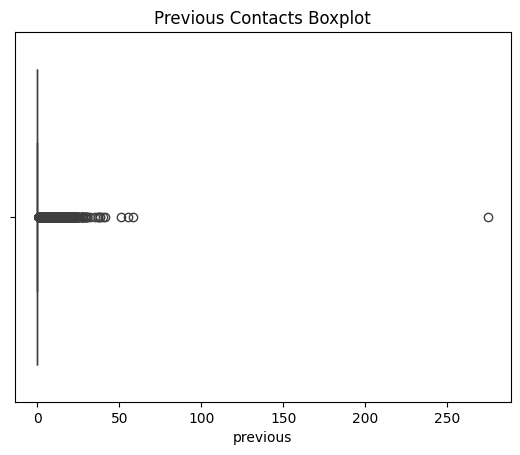

In [44]:
# Vẽ biểu đồ hộp số lần liên lạc trong chiến dịch, kiểm tra ngoại lệ
sns.boxplot(x=df['previous'], orient='h')
plt.title('Previous Contacts Boxplot')
plt.show()

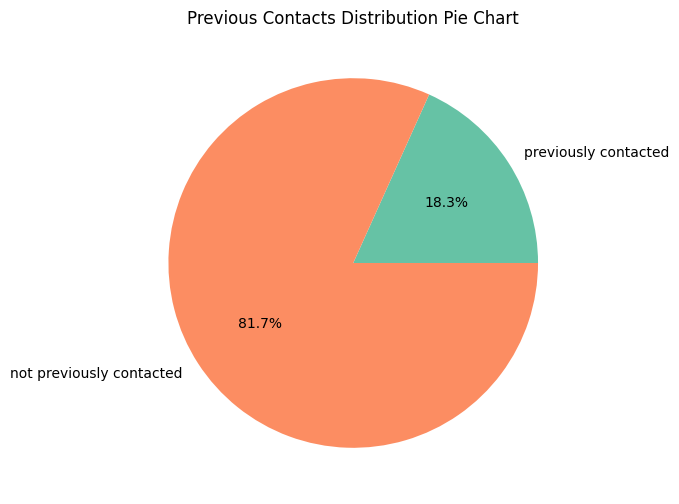

In [45]:
# Vẽ biểu đồ phân phối số lần liên lạc trong chiến dịch, kiểm tra ngoại lệ
pos_previous_counts = df['previous'][df['previous'] > 0].count()
neg_previous_counts = df['previous'][df['previous'] == 0].count()

labels = ['previously contacted', 'not previously contacted']
counts = [pos_previous_counts, neg_previous_counts]

plt.figure(figsize=(6,6))
plt.pie(counts, labels=labels, autopct='%1.1f%%', colors=sns.color_palette('Set2'))
plt.title('Previous Contacts Distribution Pie Chart')   
plt.show()

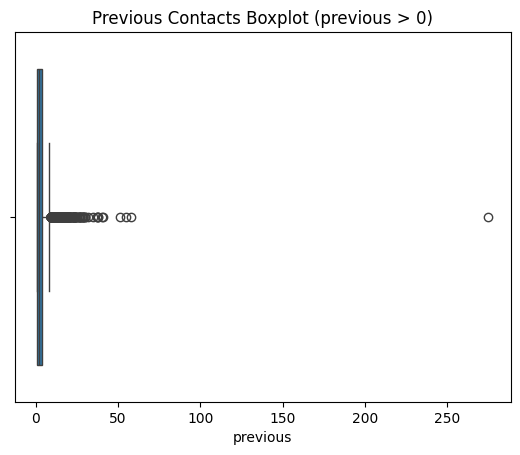

In [46]:
# Vẽ biểu đồ hộp số lần liên lạc trong chiến dịch, kiểm tra ngoại lệ
sns.boxplot(df['previous'][df['previous'] > 0], orient='h')
plt.title('Previous Contacts Boxplot (previous > 0)')
plt.show()

In [47]:
# Tính tiếp IQR nếu chỉ xét previous > 0
new_previous = df['previous'][df['previous'] > 0]
Q1 = np.percentile(new_previous, 25)
Q3 = np.percentile(new_previous, 75)
IQR = Q3 - Q1
upper_whisker = Q3 + 1.5 * IQR
print(f"IQR: {IQR},\nUpper whisker: {upper_whisker}")

IQR: 3.0,
Upper whisker: 8.5


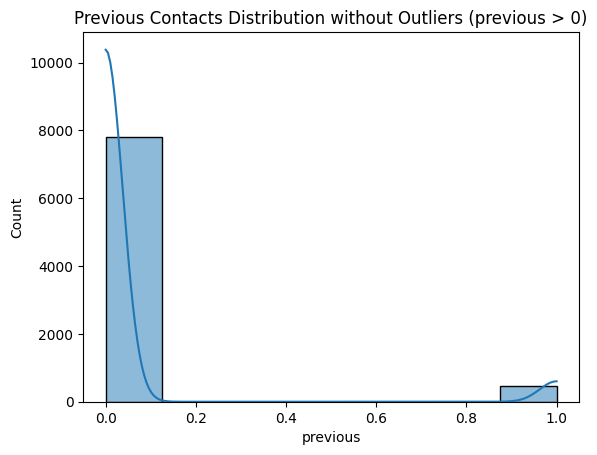

In [48]:
# Vẽ lại histogram không có outlier previous > 0
sns.histplot(new_previous >= upper_whisker, bins = 8, kde=True )
plt.title('Previous Contacts Distribution without Outliers (previous > 0)')
plt.show()

Dựa trên các biểu đồ của hai cột pdays và previous, ta có thể thấy rõ rằng:
Nếu coi hai cột này như thuộc tính phân loại (categorical features), tức là chỉ xem khách hàng đã từng được liên hệ trước đây hay chưa, thay vì xem giá trị số cụ thể ta có thể hiểu:
- Hai cột này thể hiện cùng một thông tin về việc khách hàng đã từng được liên hệ trước đây hay không. Cụ thể: 
    - Trong cột pdays, -1 có nghĩa là không từng liên hệ trước đây.
    - Trong cột previous, 0 có nghĩa là không có lần liên hệ nào trước chiến dịch này.
- Vì vậy, khi phân loại khách hàng thành hai nhóm:
    - Đã từng được liên hệ trước đây
    - Chưa từng được liên hệ
→ pdays và previous đưa ra kết luận trùng khớp và tương ứng với nhau.

#### poutcome
- Cột này biểu thị kết quả của chiến dịch marketing trước đó đối với mỗi khách hàng.
- Trong cột này có một giá trị đặc biệt: "unknown" (xuất hiện ở 81.74% các bản ghi).
=> Điều này cho thấy phần lớn khách hàng không biết hoặc không tham gia vào chiến dịch marketing trước đó.
=> unknown ở đây KHÔNG phải là 1 giá trị missing value -> 1 giá trị dữ liệu thực.

C:\Users\Admin\AppData\Local\Temp\ipykernel_21884\1697349738.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df, x='poutcome', palette='Set2', legend=False)


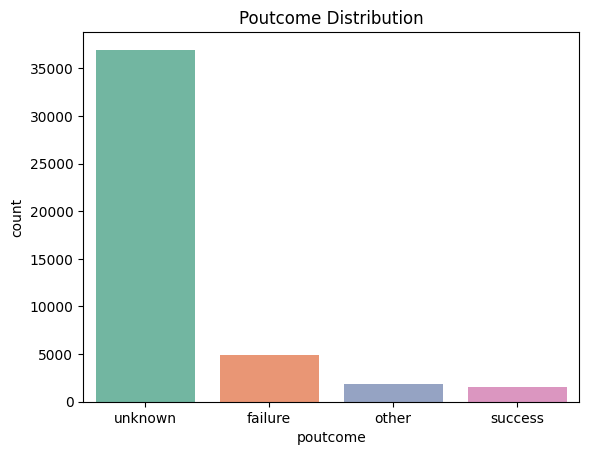

In [49]:
# Vẽ biểu đồ phân phối kết quả chiến dịch trước đó
sns.countplot(df, x='poutcome', palette='Set2', legend=False)
plt.title('Poutcome Distribution')
plt.show()

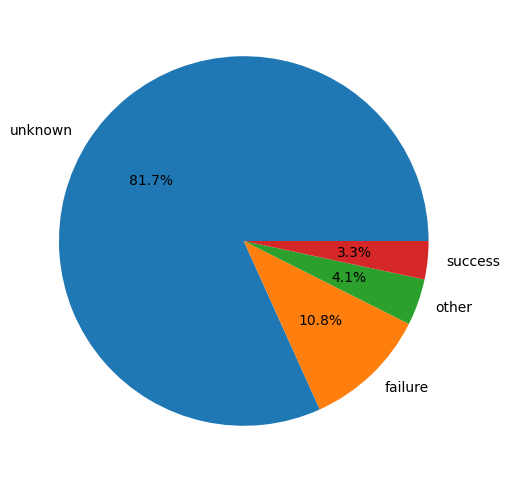

In [50]:
# Tính phân phối của poutcome
poutcome_counts = df['poutcome'].value_counts()
plt.figure(figsize = (6,6))
plt.pie(poutcome_counts, labels=poutcome_counts.index, autopct='%1.1f%%')
plt.show()

#### y
- Cột này biểu thị khách hàng có đăng ký gửi tiết kiệm có kỳ hạn (term deposit) hay không.
    - Đây là biến mục tiêu (target variable) trong bài toán phân tích/dự đoán.
    - Dữ liệu bị mất cân bằng nghiêm trọng (highly imbalanced), tức là số lượng khách hàng không đăng ký nhiều hơn đáng kể so với số lượng khách hàng có đăng ký.
=> Điều này cần lưu ý khi xây dựng mô hình, vì mô hình có thể bị thiên lệch về phía nhóm chiếm ưu thế nếu không xử lý cân bằng dữ liệu (ví dụ: dùng SMOTE, class weighting, hoặc sampling).

C:\Users\Admin\AppData\Local\Temp\ipykernel_21884\2844734127.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df, x= 'y', palette='Set1', legend=False)


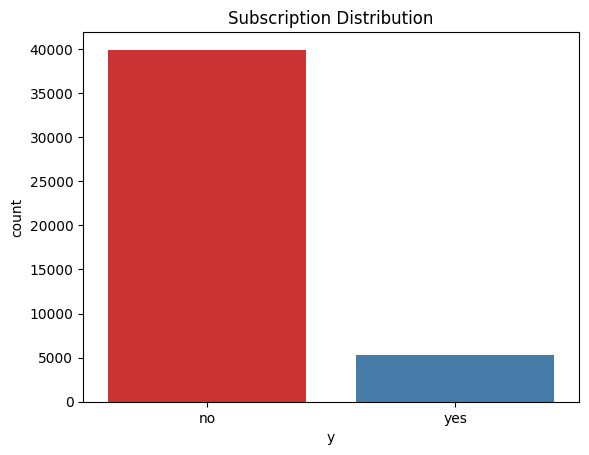

In [51]:
# Vẽ biểu đồ phân phối kết quả chiến dịch trước đó
sns.countplot(df, x= 'y', palette='Set1', legend=False)
plt.title('Subscription Distribution')
plt.show()

In [52]:
# Tính phân phối của y
df['y'].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

#### Phân tích tương quan giữa biến số và biến mục tiêu y (bivariate)
- Nhìn chung, không có mối tương quan mạnh nào giữa các biến đặc trưng (features) trong dataset.
- Một mối tương quan đáng chú ý là 0.45 giữa pdays và previous. Như đã giải thích trước đó, cả hai biến này đều phản ánh việc khách hàng đã từng được liên hệ trong chiến dịch trước hay chưa, nên chúng có mối quan hệ trung bình khá với nhau.
- Ngoài ra, có mối tương quan 0.39 giữa duration và biến mục tiêu (y). Điều này cho thấy thời lượng liên hệ gần nhất với khách hàng có liên quan vừa phải đến việc khách hàng có đăng ký term deposit hay không. Thường các giá trị duration dài hơn có khả năng khách hàng đăng ký cao hơn.

In [53]:
# Tính ma trận tương quan
df_copy = df.copy()
df_copy['y'] = df_copy['y'].replace({"yes": 1 , "no": 0})
numeric_data = df_copy.select_dtypes(include=[np.number])
correlation_matrix = numeric_data.corr()
correlation_matrix

C:\Users\Admin\AppData\Local\Temp\ipykernel_21884\2534982809.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_copy['y'] = df_copy['y'].replace({"yes": 1 , "no": 0})


,age,balance,day,duration,campaign,pdays,previous,y
age,1.000000,0.097783,-0.009120,-0.004648,0.004760,-0.023758,0.001288,0.025155
balance,0.097783,1.000000,0.004503,0.021560,-0.014578,0.003435,0.016674,0.052838
day,-0.009120,0.004503,1.000000,-0.030206,0.162490,-0.093044,-0.051710,-0.028348
duration,-0.004648,0.021560,-0.030206,1.000000,-0.084570,-0.001565,0.001203,0.394521
campaign,0.004760,-0.014578,0.162490,-0.084570,1.000000,-0.088628,-0.032855,-0.073172
pdays,-0.023758,0.003435,-0.093044,-0.001565,-0.088628,1.000000,0.454820,0.103621
previous,0.001288,0.016674,-0.051710,0.001203,-0.032855,0.454820,1.000000,0.093236
y,0.025155,0.052838,-0.028348,0.394521,-0.073172,0.103621,0.093236,1.000000


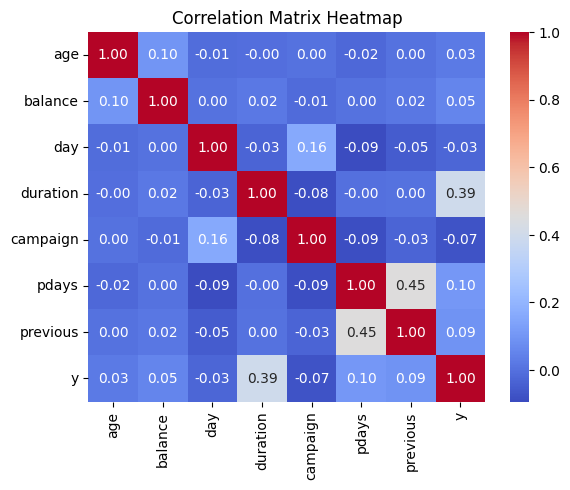

In [54]:
# Vẽ heatmap ma trận tương quan
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()

Vì có quá ít sự tương quan mạnh giữa 2 biến với nhau, nên ta sẽ thử phân tích xem các biến đó tương quan như thế nào, tại sao lại ít?

In [62]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


Trước khi tiến hành đi sâu về phân tích sự tương quan giữa các biến, ta xem lại phần mô tả của các thuộc tính trên, có thể thấy được rằng: 
1. age (tuổi): Dữ liệu cho thấy độ tuổi của khách hàng có thể mở đăng ký gửi tiền cao nhất có thể lên đến 95 tuổi, đây là một điểm đặc biệt trong phân tích, nên sẽ xem thử phần độ tuổi cao này có xu hướng đăng ký gửi nhiều hay ít không
2. balance (số dư tài khoản): phần mô tả trên cho thấy có số dư thấp nhất là -8019 (tức là bị vay nợ nhiều hoặc gặp trục trặc gì đó (?)), cần xem thử đây là giá trị lỗi hay là do các yếu tố ngoài nào tác động đến số dư tài khoản của khách hàng (như vay nợ ngân hàng, hoặc gặp khó khăn khủng hoảng tài chính,...)
3. duration (thời lượng cuộc gọi cuối): đây được tính theo đơn vị giây (s), tuy nhiên giá trị max ở đây là 4918s tức gần 81 phút, điều này là vô lý vì không có chiến dịch marketing nào hay cuộc gọi quảng cáo nào tới khách hàng có thể chiếm dụng tới 81 phút -> cần xem xét và loại bỏ
4. campaign (số lần liên hệ trong chiến dịch hiện tại): tương tự, phần max ở dây là 63 lần, tức là có 1 khách hàng được tư vấn dịch vụ này tới tận 63 lần (cùng 1 chiến dịch), điều này hơi khó hiểu và gần như không xảy ra trong thực tế -> xem xét loại bỏ
5. pdays (số ngày kể từ lần cuối liên hệ cuối của chiến dịch trước): min là -1 (chưa từng liên hệ), và max là 871 tức là hơn 2 năm không liên hệ (có thể có) -> vẫn giữ nếu không ảnh hưởng quá trình dến mô hình học sau này
6. day và previous tạm thời đã ổn (sau khi đã xử lý các outliers ở trên)

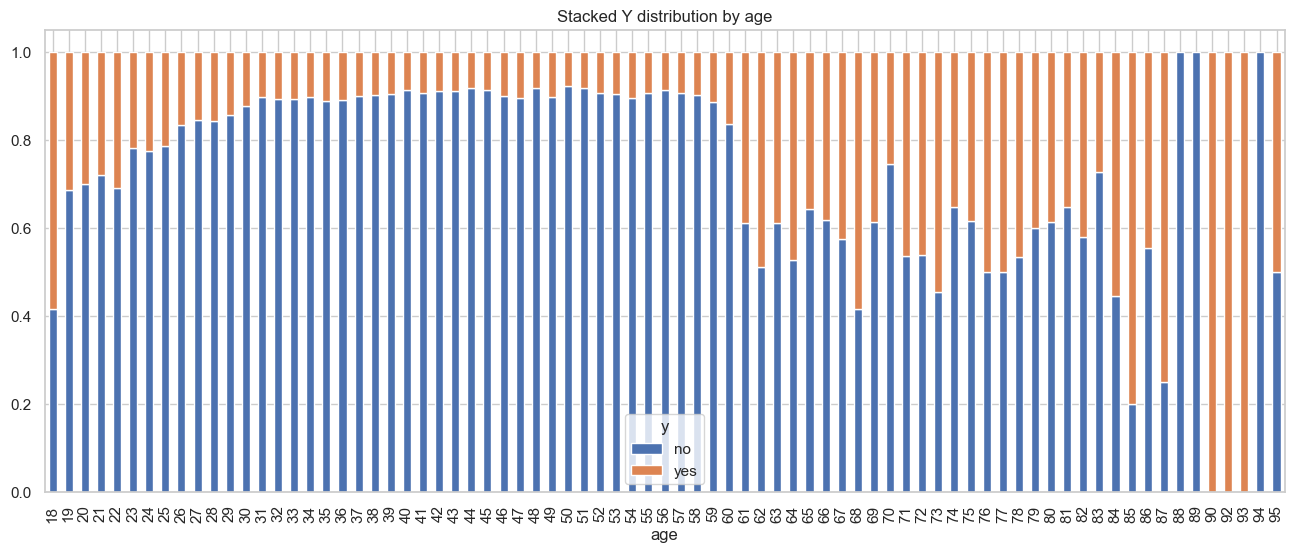

In [64]:
# Phân tích sự tương quan giữa phân phối Age và biến mục tiêu (y)
df.groupby('age')['y'].value_counts(normalize=True).unstack().plot(
    kind='bar',
    stacked=True,
    figsize=(16,6)
)
plt.xticks(rotation=90)
plt.title('Stacked Y distribution by age')
plt.show()


Từ đây có thể thấy được là nhóm khách hàng có độ tuổi từ 60 trở lên sẽ có xu hướng chọn đăng ký gửi tiền tại ngân hàng, trong khi nhóm khách hàng ở độ tuổi trẻ từ 19 tới dưới 60 thì lại không

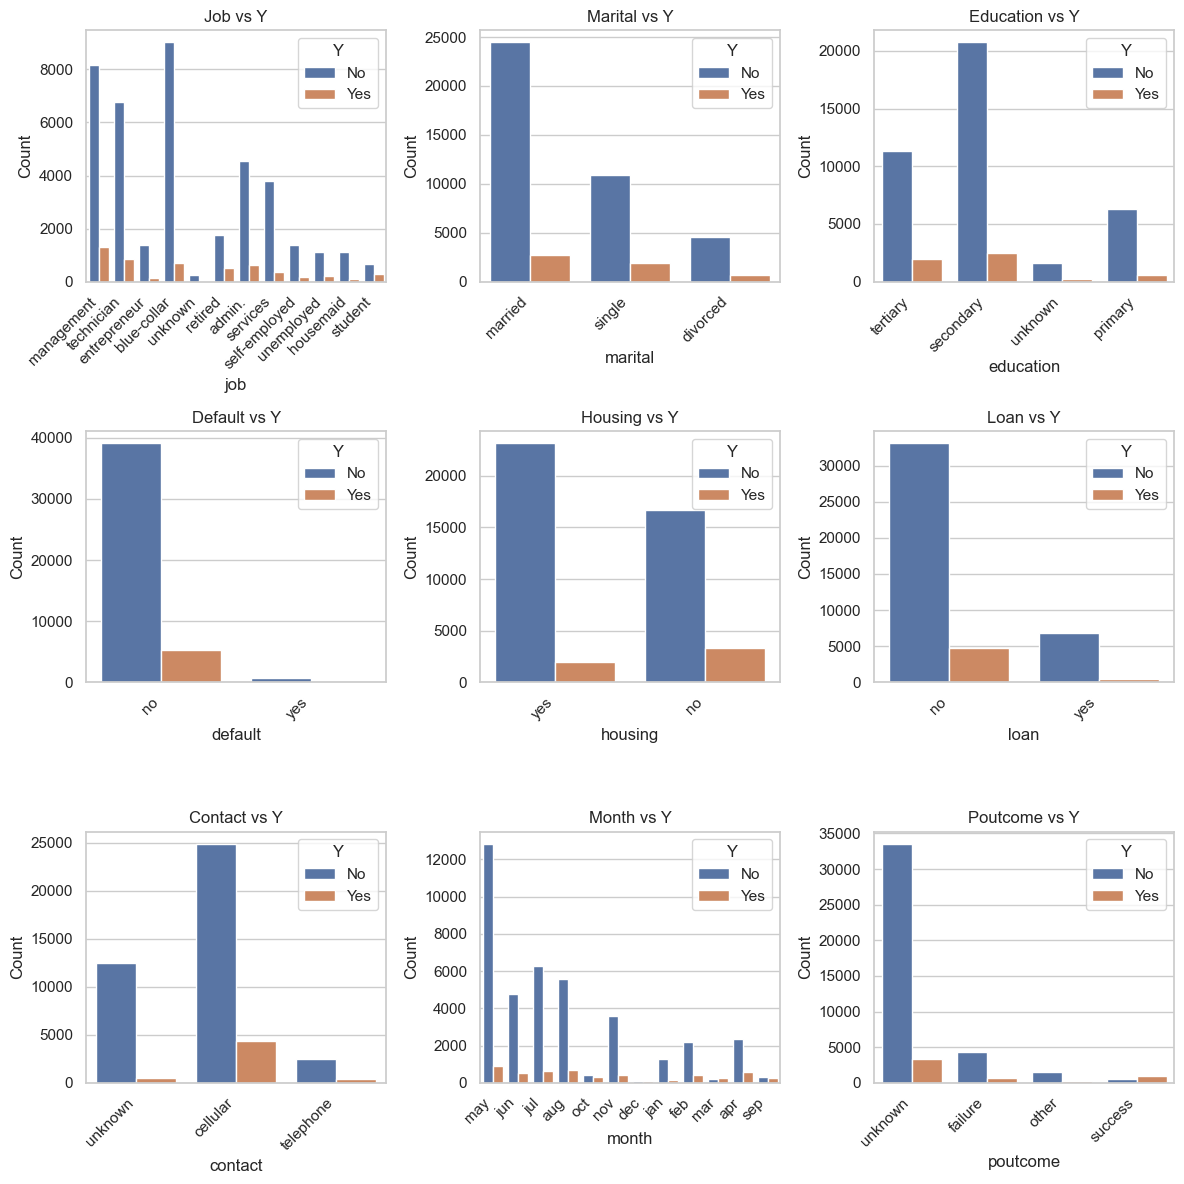

In [65]:
categorical_columns = df.select_dtypes(include=['object']).columns.drop('y')

sns.set(style= "whitegrid")
plt.figure(figsize=(12,12))

for i, col in enumerate(categorical_columns, 1):
    plt.subplot(3,3,i)
    sns.countplot(x=col, hue='y', data=df)
    plt.title(f"{col.title()} vs Y")
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Y', labels=['No', 'Yes'])
    
plt.tight_layout()
plt.show()

Từ phần biểu diễn các phân phối trên có thể thấy được rằng:
1. job (nghề nghiệp): nhóm khách hàng có nghề nghiệp về quản lý "management" thì sẽ có xu hướng đăng ký gửi tiền cao nhất, những khách hàng làm "entrepreneur" và "housemaid" là thấp nhất
2. marital (tình trạng hôn nhân): người đã kết hôn (married) có tỷ lệ đăng ký cao nhất, trong khi người ly hôn (divorced) có tỷ lệ đăng ký thấp nhất. 
3. education (trình độ học vấn): nhóm khách hàng có trình độ secondary đăng ký nhiều nhất, còn nhóm primary đăng ký ít nhất.
4. default (tín dụng quá hạn): khách hàng không có nợ xấu (no default) đăng ký nhiều hơn đáng kể, con những người có nợ xấu (default) hầu như không đăng ký.
5. housing (khoản vay mua nhà): khách hàng không có khoản vay mua nhà đăng ký nhiều hơn, nhóm có housing loan có tỷ lệ đăng ký thấp hơn.
6. loan (khoản vay cá nhân): khách hàng không có personal loan đăng ký nhiều nhất, ngược lại với những người có personal loan thì đăng ký rất ít.
7. contact (phương thức liên hệ): phân phối trên cho thấy xu hướng liên hệ qua cellular có tỷ lệ đăng ký cao hơn so với qua telephone.
8. month (tháng liên hệ): biểu đồ trên cho thấy là tháng 5 (may) có số lượng đăng ký nhiều nhất, còn tháng 3 (march) và tháng 12 (december) là đăng ký ít nhất
9. poutcome (kết quả chiến dịch trước): Những khách hàng có kết quả chiến dịch trước là success đăng ký nhiều nhất, còn các khách hàng có kết quả failure hoặc other đăng ký ít hơn. Nhóm unknown chiếm số lượng lớn nhất => Không thể giả định rằng họ đã thành công hay thất bại trong chiến dịch trước vì thiếu thông tin => Cần thêm dữ liệu hoặc mô tả để đưa ra kết luận chắc chắn.

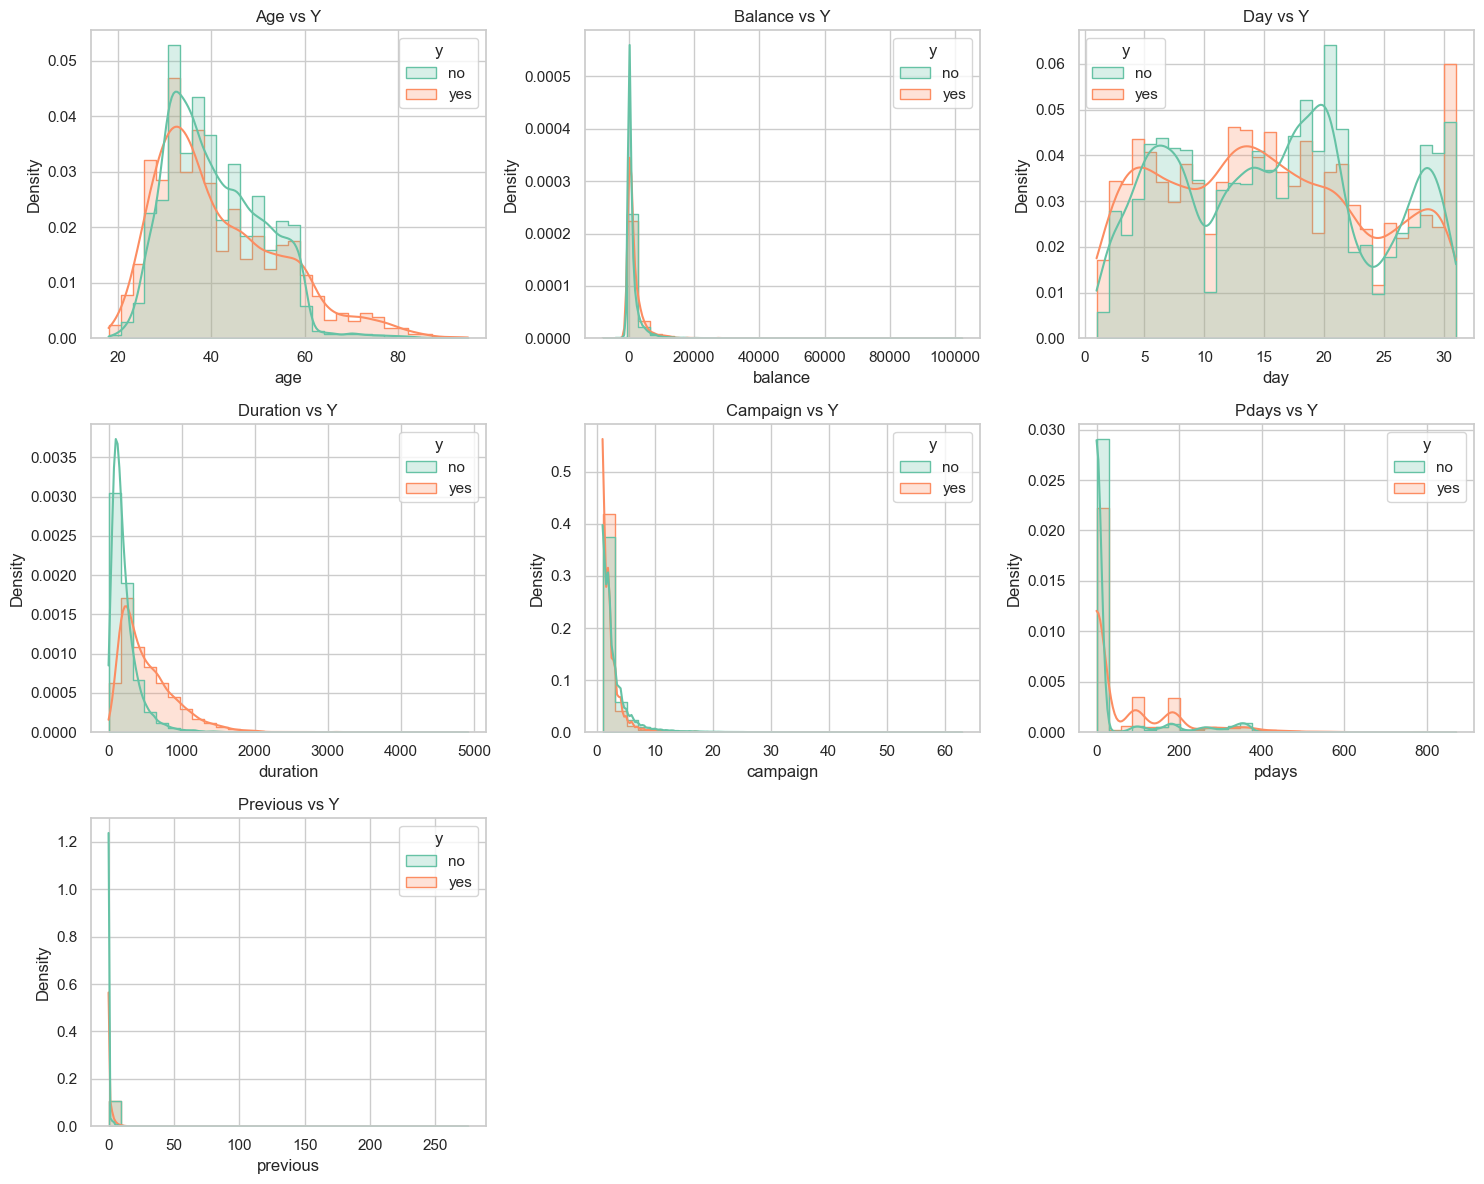

In [69]:
interger_columns = df.select_dtypes(include=['int64']).columns

n_cols = 3
n_rows = int(np.ceil(len(interger_columns)/n_cols))

plt.figure(figsize=(n_cols*5, n_rows*4))

for i, col in enumerate(interger_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(data=df, x=col, hue='y', bins=30, kde=True,
                 palette='Set2', element='step', stat='density', common_norm=False)
    plt.title(f"{col.title()} vs Y")
    plt.xlabel(col)
    plt.ylabel('Density')

plt.tight_layout()
plt.show()

Từ các biểu đồ biểu diễn trên, ta phân tích được:
1. age (tuổi): những khách hàng đăng ký thành công thường ở nhóm tuổi >60, mật độ tập trung rõ rệt ở nhóm không đăng ký (30-60).
2. balance (số dư tài khoản): Khách hàng có số dư tài khoản cao hơn thường có khả năng đăng ký cao hơn. Nhóm không đăng ký tập trung nhiều ở mức số dư thấp… Tuy nhiên, cả hai nhóm (đăng ký và không đăng ký) đều tập trung mạnh ở mức số dư thấp -> dễ thấy xu hướng tập trung nhiều ở nhóm có số dư thấp hơn là cao
3. day (ngày trong tháng): phân bố đồng đều cả về đăng ký và không đăng ký ở các ngày trong tháng
4. duration (thời lượng cuộc gọi): Phân phối cho thấy thời lượng cuộc gọi có ảnh hưởng rất mạnh, các cuộc gọi kéo dài hơn (có thời gian lâu) có liên quan chặt chẽ đến khả năng đăng ký thành công.
5. campaign (số lần liên hệ trong chiến dịch hiện tại): Số lần liên hệ ít (1–3 lần) mang lại hiệu quả cao hơn, xác suất đăng ký giảm khi số lần liên hệ tăng => có thể hiểu là nếu sau 3 lần mà khách hàng vẫn không quan tâm thì khả năng họ không muốn đăng ký là rất cao.
6. pdays (số ngày liên hệ từ lần trước đó): Tỷ lệ đăng ký cao nhất xuất hiện ở nhóm khách hàng được liên hệ gần đây (pdays thấp). Tuy nhiên vẫn có một số khách hàng đăng ký sau một thời gian rất dài không được liên hệ => Có thể suy luận rằng, sẽ có một số yếu tố bên ngoài (không phải là các cuộc gọi marketing) tác động đến quyết định của khách hàng như tình trạng tài chính cá nhân khả quan, được người quen giới thiệu, mới trúng số,... chưa thể đưa ra kết luận cụ thể về lý do tại sao như vậy.
7. previous (số lần liên hệ trong các chiến dịch trước): Số lần những khách hàng được liên hệ ít hơn trong quá khứ (đặc biệt 1–2 lần) có tỷ lệ thành công cao hơn, trong khi xác suất đó lại giảm khi số lần liên hệ trước đó tăng lên. Tuy nhiên, một lượng lớn người đăng ký lại thuộc nhóm chưa từng được liên hệ trước đây; điều này cho thấy việc liên hệ trước có ích nhưng không phải là yếu tố bắt buộc. Cần phân tích sâu hơn để rút ra kết luận chắc chắn.

Để hiểu rõ data hơn, cần phân tích dự đoán (Predictive analytics) là dùng các model Machine Learning để đưa ra các kết luận về dự đoán và tối ưu hóa mô hình hơn, và trước tiên cần tiền xử lý dữ liệu và chọn ra các đặc trưng quan trọng.